# Unsupervised Machine Learning Project
## Customer Behavior Segmentation + Dimensionality Reduction + Anomaly Detection

**Dataset:** `Customer_Behavior_Unsupervised_Dataset.csv`

Is project mein aap ek hi dataset par ye topics cover karain gy

- Feature Extraction & Engineering
- PCA
- t-SNE
- K-Means Clustering
- Hierarchical Clustering
- DBSCAN
- Anomaly Detection
- Cluster Profiling & Business Insights



In [1]:
# Install if needed:
# pip install pandas numpy matplotlib scikit-learn scipy openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

import warnings
warnings.filterwarnings('ignore')

## 1. Load Dataset

In [2]:
df = pd.read_csv('Customer_Behavior_Unsupervised_Dataset.csv')
df.head()

,Customer_ID,Age,Gender,City,Annual_Income,Monthly_Spending,Visits_Per_Month,Online_Orders,Avg_Order_Value,Time_on_Website_Min,Discount_Usage,Satisfaction_Score
0,C0001,58,Male,Karachi,174194,18203,8,8,2179,289,0.09,3.6
1,C0002,19,Male,Lahore,151981,23474,7,6,3757,289,0.42,3.6
2,C0003,35,Male,Lahore,251571,90441,7,7,13009,62,0.09,2.7
3,C0004,40,Female,Karachi,270870,500,1,0,6701,292,0.29,4.1
4,C0005,41,Male,Karachi,54025,3310,5,1,1807,129,0.87,3.5


In [3]:
print(df.shape)
df.info()

(1000, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Customer_ID          1000 non-null   object 
 1   Age                  1000 non-null   int64  
 2   Gender               1000 non-null   object 
 3   City                 1000 non-null   object 
 4   Annual_Income        1000 non-null   int64  
 5   Monthly_Spending     1000 non-null   int64  
 6   Visits_Per_Month     1000 non-null   int64  
 7   Online_Orders        1000 non-null   int64  
 8   Avg_Order_Value      1000 non-null   int64  
 9   Time_on_Website_Min  1000 non-null   int64  
 10  Discount_Usage       1000 non-null   float64
 11  Satisfaction_Score   1000 non-null   float64
dtypes: float64(2), int64(7), object(3)
memory usage: 93.9+ KB


## 2. Basic Data Cleaning Check

In [4]:
print('Missing values:')
print(df.isnull().sum())

Missing values:
Customer_ID            0
Age                    0
Gender                 0
City                   0
Annual_Income          0
Monthly_Spending       0
Visits_Per_Month       0
Online_Orders          0
Avg_Order_Value        0
Time_on_Website_Min    0
Discount_Usage         0
Satisfaction_Score     0
dtype: int64


In [5]:
print('Duplicate rows:', df.duplicated().sum())

Duplicate rows: 0


In [6]:
df.describe()

,Age,Annual_Income,Monthly_Spending,Visits_Per_Month,Online_Orders,Avg_Order_Value,Time_on_Website_Min,Discount_Usage,Satisfaction_Score
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,41.311000,167926.746000,45111.414000,7.411000,6.191000,8497.485000,156.042000,0.502500,3.742900
std,14.286791,78050.778205,37092.037904,3.060628,3.420266,13609.923576,85.604266,0.286481,0.713455
min,18.000000,30629.000000,500.000000,1.000000,0.000000,522.000000,5.000000,0.000000,2.500000
25%,28.000000,100633.000000,15684.000000,5.000000,4.000000,3981.500000,80.750000,0.250000,3.100000
50%,41.000000,171250.000000,35833.000000,7.000000,6.000000,7479.500000,157.000000,0.500000,3.700000
75%,54.000000,234854.000000,65345.750000,9.250000,9.000000,11191.750000,229.000000,0.750000,4.400000
max,65.000000,299997.000000,233160.000000,16.000000,17.000000,233160.000000,300.000000,1.000000,5.000000


## 3. Feature Engineering

Yahan raw data se meaningful features create kiye jayenge.

Examples:
- `Spending_Ratio`: income ke comparison mein spending
- `Avg_Spend_Per_Visit`: har visit par average spending
- `Online_Order_Ratio`: visits ke comparison mein online orders
- `Customer_Value`: online order value ka estimated value
- `Engagement_Score`: website time + visits + online orders ka combined score

In [8]:
df

,Customer_ID,Age,Gender,City,Annual_Income,Monthly_Spending,Visits_Per_Month,Online_Orders,Avg_Order_Value,Time_on_Website_Min,Discount_Usage,Satisfaction_Score
0,C0001,58,Male,Karachi,174194,18203,8,8,2179,289,0.09,3.6
1,C0002,19,Male,Lahore,151981,23474,7,6,3757,289,0.42,3.6
2,C0003,35,Male,Lahore,251571,90441,7,7,13009,62,0.09,2.7
3,C0004,40,Female,Karachi,270870,500,1,0,6701,292,0.29,4.1
4,C0005,41,Male,Karachi,54025,3310,5,1,1807,129,0.87,3.5
...,...,...,...,...,...,...,...,...,...,...,...,...
995,C0996,18,Male,Peshawar,46489,41840,10,10,6181,289,0.01,3.8
996,C0997,34,Male,Lahore,45495,37525,4,3,12967,120,0.87,2.8
997,C0998,31,Male,Islamabad,102647,24826,8,10,2573,150,0.48,4.9
998,C0999,40,Female,Faisalabad,289942,6350,1,2,3663,98,0.20,4.6


In [9]:
df_fe = df.copy()
df_fe

,Customer_ID,Age,Gender,City,Annual_Income,Monthly_Spending,Visits_Per_Month,Online_Orders,Avg_Order_Value,Time_on_Website_Min,Discount_Usage,Satisfaction_Score
0,C0001,58,Male,Karachi,174194,18203,8,8,2179,289,0.09,3.6
1,C0002,19,Male,Lahore,151981,23474,7,6,3757,289,0.42,3.6
2,C0003,35,Male,Lahore,251571,90441,7,7,13009,62,0.09,2.7
3,C0004,40,Female,Karachi,270870,500,1,0,6701,292,0.29,4.1
4,C0005,41,Male,Karachi,54025,3310,5,1,1807,129,0.87,3.5
...,...,...,...,...,...,...,...,...,...,...,...,...
995,C0996,18,Male,Peshawar,46489,41840,10,10,6181,289,0.01,3.8
996,C0997,34,Male,Lahore,45495,37525,4,3,12967,120,0.87,2.8
997,C0998,31,Male,Islamabad,102647,24826,8,10,2573,150,0.48,4.9
998,C0999,40,Female,Faisalabad,289942,6350,1,2,3663,98,0.20,4.6


In [10]:
df_fe.columns

Index(['Customer_ID', 'Age', 'Gender', 'City', 'Annual_Income',
       'Monthly_Spending', 'Visits_Per_Month', 'Online_Orders',
       'Avg_Order_Value', 'Time_on_Website_Min', 'Discount_Usage',
       'Satisfaction_Score'],
      dtype='object')

In [11]:
df_fe['Spending_Ratio'] = df_fe['Monthly_Spending'] / df_fe['Annual_Income']

In [14]:
df_fe

,Customer_ID,Age,Gender,City,Annual_Income,Monthly_Spending,Visits_Per_Month,Online_Orders,Avg_Order_Value,Time_on_Website_Min,Discount_Usage,Satisfaction_Score,Spending_Ratio
0,C0001,58,Male,Karachi,174194,18203,8,8,2179,289,0.09,3.6,0.104498
1,C0002,19,Male,Lahore,151981,23474,7,6,3757,289,0.42,3.6,0.154454
2,C0003,35,Male,Lahore,251571,90441,7,7,13009,62,0.09,2.7,0.359505
3,C0004,40,Female,Karachi,270870,500,1,0,6701,292,0.29,4.1,0.001846
4,C0005,41,Male,Karachi,54025,3310,5,1,1807,129,0.87,3.5,0.061268
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,C0996,18,Male,Peshawar,46489,41840,10,10,6181,289,0.01,3.8,0.899998
996,C0997,34,Male,Lahore,45495,37525,4,3,12967,120,0.87,2.8,0.824816
997,C0998,31,Male,Islamabad,102647,24826,8,10,2573,150,0.48,4.9,0.241858
998,C0999,40,Female,Faisalabad,289942,6350,1,2,3663,98,0.20,4.6,0.021901


In [12]:
df_fe.head()

,Customer_ID,Age,Gender,City,Annual_Income,Monthly_Spending,Visits_Per_Month,Online_Orders,Avg_Order_Value,Time_on_Website_Min,Discount_Usage,Satisfaction_Score,Spending_Ratio
0,C0001,58,Male,Karachi,174194,18203,8,8,2179,289,0.09,3.6,0.104498
1,C0002,19,Male,Lahore,151981,23474,7,6,3757,289,0.42,3.6,0.154454
2,C0003,35,Male,Lahore,251571,90441,7,7,13009,62,0.09,2.7,0.359505
3,C0004,40,Female,Karachi,270870,500,1,0,6701,292,0.29,4.1,0.001846
4,C0005,41,Male,Karachi,54025,3310,5,1,1807,129,0.87,3.5,0.061268


In [13]:
df_fe.tail()

,Customer_ID,Age,Gender,City,Annual_Income,Monthly_Spending,Visits_Per_Month,Online_Orders,Avg_Order_Value,Time_on_Website_Min,Discount_Usage,Satisfaction_Score,Spending_Ratio
995,C0996,18,Male,Peshawar,46489,41840,10,10,6181,289,0.01,3.8,0.899998
996,C0997,34,Male,Lahore,45495,37525,4,3,12967,120,0.87,2.8,0.824816
997,C0998,31,Male,Islamabad,102647,24826,8,10,2573,150,0.48,4.9,0.241858
998,C0999,40,Female,Faisalabad,289942,6350,1,2,3663,98,0.20,4.6,0.021901
999,C1000,63,Female,Faisalabad,83946,500,3,0,5605,115,0.95,3.7,0.005956


In [15]:
df_fe.Visits_Per_Month.unique()

array([ 8,  7,  1,  5, 11,  6, 10, 14,  9, 12,  3,  4, 16,  2, 13, 15])

Agar `Visits_Per_Month` mein kisi customer ki value 0 hai, to usay temporary 1 se replace kar do, taake division error na aaye.

In [16]:
df_fe['Avg_Spend_Per_Visit'] = df_fe['Monthly_Spending'] / df_fe['Visits_Per_Month'].replace(0, 1)


In [17]:
df_fe

,Customer_ID,Age,Gender,City,Annual_Income,Monthly_Spending,Visits_Per_Month,Online_Orders,Avg_Order_Value,Time_on_Website_Min,Discount_Usage,Satisfaction_Score,Spending_Ratio,Avg_Spend_Per_Visit
0,C0001,58,Male,Karachi,174194,18203,8,8,2179,289,0.09,3.6,0.104498,2275.375000
1,C0002,19,Male,Lahore,151981,23474,7,6,3757,289,0.42,3.6,0.154454,3353.428571
2,C0003,35,Male,Lahore,251571,90441,7,7,13009,62,0.09,2.7,0.359505,12920.142857
3,C0004,40,Female,Karachi,270870,500,1,0,6701,292,0.29,4.1,0.001846,500.000000
4,C0005,41,Male,Karachi,54025,3310,5,1,1807,129,0.87,3.5,0.061268,662.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,C0996,18,Male,Peshawar,46489,41840,10,10,6181,289,0.01,3.8,0.899998,4184.000000
996,C0997,34,Male,Lahore,45495,37525,4,3,12967,120,0.87,2.8,0.824816,9381.250000
997,C0998,31,Male,Islamabad,102647,24826,8,10,2573,150,0.48,4.9,0.241858,3103.250000
998,C0999,40,Female,Faisalabad,289942,6350,1,2,3663,98,0.20,4.6,0.021901,6350.000000


In [18]:
df_fe['Online_Order_Ratio'] = df_fe['Online_Orders'] / df_fe['Visits_Per_Month'].replace(0, 1)


In [19]:
df_fe

,Customer_ID,Age,Gender,City,Annual_Income,Monthly_Spending,Visits_Per_Month,Online_Orders,Avg_Order_Value,Time_on_Website_Min,Discount_Usage,Satisfaction_Score,Spending_Ratio,Avg_Spend_Per_Visit,Online_Order_Ratio
0,C0001,58,Male,Karachi,174194,18203,8,8,2179,289,0.09,3.6,0.104498,2275.375000,1.000000
1,C0002,19,Male,Lahore,151981,23474,7,6,3757,289,0.42,3.6,0.154454,3353.428571,0.857143
2,C0003,35,Male,Lahore,251571,90441,7,7,13009,62,0.09,2.7,0.359505,12920.142857,1.000000
3,C0004,40,Female,Karachi,270870,500,1,0,6701,292,0.29,4.1,0.001846,500.000000,0.000000
4,C0005,41,Male,Karachi,54025,3310,5,1,1807,129,0.87,3.5,0.061268,662.000000,0.200000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,C0996,18,Male,Peshawar,46489,41840,10,10,6181,289,0.01,3.8,0.899998,4184.000000,1.000000
996,C0997,34,Male,Lahore,45495,37525,4,3,12967,120,0.87,2.8,0.824816,9381.250000,0.750000
997,C0998,31,Male,Islamabad,102647,24826,8,10,2573,150,0.48,4.9,0.241858,3103.250000,1.250000
998,C0999,40,Female,Faisalabad,289942,6350,1,2,3663,98,0.20,4.6,0.021901,6350.000000,2.000000


In [20]:
df_fe['Customer_Value'] = df_fe['Avg_Order_Value'] * df_fe['Online_Orders']


In [21]:
df_fe

,Customer_ID,Age,Gender,City,Annual_Income,Monthly_Spending,Visits_Per_Month,Online_Orders,Avg_Order_Value,Time_on_Website_Min,Discount_Usage,Satisfaction_Score,Spending_Ratio,Avg_Spend_Per_Visit,Online_Order_Ratio,Customer_Value
0,C0001,58,Male,Karachi,174194,18203,8,8,2179,289,0.09,3.6,0.104498,2275.375000,1.000000,17432
1,C0002,19,Male,Lahore,151981,23474,7,6,3757,289,0.42,3.6,0.154454,3353.428571,0.857143,22542
2,C0003,35,Male,Lahore,251571,90441,7,7,13009,62,0.09,2.7,0.359505,12920.142857,1.000000,91063
3,C0004,40,Female,Karachi,270870,500,1,0,6701,292,0.29,4.1,0.001846,500.000000,0.000000,0
4,C0005,41,Male,Karachi,54025,3310,5,1,1807,129,0.87,3.5,0.061268,662.000000,0.200000,1807
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,C0996,18,Male,Peshawar,46489,41840,10,10,6181,289,0.01,3.8,0.899998,4184.000000,1.000000,61810
996,C0997,34,Male,Lahore,45495,37525,4,3,12967,120,0.87,2.8,0.824816,9381.250000,0.750000,38901
997,C0998,31,Male,Islamabad,102647,24826,8,10,2573,150,0.48,4.9,0.241858,3103.250000,1.250000,25730
998,C0999,40,Female,Faisalabad,289942,6350,1,2,3663,98,0.20,4.6,0.021901,6350.000000,2.000000,7326


## Engagement Score hota kya hai?

Company ye dekhna chahti hai ke customer kitna active (engaged) hai.

Is activity ko measure karne ke liye hum ne 3 cheezen use ki hain:

`Visits_Per_Month`
`Online_Orders`
`Time_on_Website_Min`

Lekin ye tino equally important nahi hain.

Isliye hum ne weights diye hain.

`Visits_Per_Month     → 40%`
`Online_Orders        → 40%`
`Time_on_Website_Min  → 20%`

### Ye 0.4 aur 0.2 kahan se aaye?

Ye fixed values nahi hain.

Ye sirf assumption (business rule) hai.

`Visits × 40%`

`Orders × 40%`

`Time × 20%`

Engagement =

10 × 0.4 = 4

8 × 0.4 = 3.2

150 × 0.2 = 30

Final

4 + 3.2 + 30

= 37.2




In [22]:
df_fe['Engagement_Score'] = (
    df_fe['Visits_Per_Month'] * 0.4 +
    df_fe['Online_Orders'] * 0.4 +
    df_fe['Time_on_Website_Min'] * 0.2
)

In [23]:
df_fe

,Customer_ID,Age,Gender,City,Annual_Income,Monthly_Spending,Visits_Per_Month,Online_Orders,Avg_Order_Value,Time_on_Website_Min,Discount_Usage,Satisfaction_Score,Spending_Ratio,Avg_Spend_Per_Visit,Online_Order_Ratio,Customer_Value,Engagement_Score
0,C0001,58,Male,Karachi,174194,18203,8,8,2179,289,0.09,3.6,0.104498,2275.375000,1.000000,17432,64.2
1,C0002,19,Male,Lahore,151981,23474,7,6,3757,289,0.42,3.6,0.154454,3353.428571,0.857143,22542,63.0
2,C0003,35,Male,Lahore,251571,90441,7,7,13009,62,0.09,2.7,0.359505,12920.142857,1.000000,91063,18.0
3,C0004,40,Female,Karachi,270870,500,1,0,6701,292,0.29,4.1,0.001846,500.000000,0.000000,0,58.8
4,C0005,41,Male,Karachi,54025,3310,5,1,1807,129,0.87,3.5,0.061268,662.000000,0.200000,1807,28.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,C0996,18,Male,Peshawar,46489,41840,10,10,6181,289,0.01,3.8,0.899998,4184.000000,1.000000,61810,65.8
996,C0997,34,Male,Lahore,45495,37525,4,3,12967,120,0.87,2.8,0.824816,9381.250000,0.750000,38901,26.8
997,C0998,31,Male,Islamabad,102647,24826,8,10,2573,150,0.48,4.9,0.241858,3103.250000,1.250000,25730,37.2
998,C0999,40,Female,Faisalabad,289942,6350,1,2,3663,98,0.20,4.6,0.021901,6350.000000,2.000000,7326,20.8


## 4. Preprocessing: Encoding + Scaling

Unsupervised ML algorithms usually numerical input require karte hain. Isliye categorical columns encode aur numerical columns scale kiye jayenge.

In [24]:
features = df_fe.drop(columns=['Customer_ID'])
features

,Age,Gender,City,Annual_Income,Monthly_Spending,Visits_Per_Month,Online_Orders,Avg_Order_Value,Time_on_Website_Min,Discount_Usage,Satisfaction_Score,Spending_Ratio,Avg_Spend_Per_Visit,Online_Order_Ratio,Customer_Value,Engagement_Score
0,58,Male,Karachi,174194,18203,8,8,2179,289,0.09,3.6,0.104498,2275.375000,1.000000,17432,64.2
1,19,Male,Lahore,151981,23474,7,6,3757,289,0.42,3.6,0.154454,3353.428571,0.857143,22542,63.0
2,35,Male,Lahore,251571,90441,7,7,13009,62,0.09,2.7,0.359505,12920.142857,1.000000,91063,18.0
3,40,Female,Karachi,270870,500,1,0,6701,292,0.29,4.1,0.001846,500.000000,0.000000,0,58.8
4,41,Male,Karachi,54025,3310,5,1,1807,129,0.87,3.5,0.061268,662.000000,0.200000,1807,28.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,18,Male,Peshawar,46489,41840,10,10,6181,289,0.01,3.8,0.899998,4184.000000,1.000000,61810,65.8
996,34,Male,Lahore,45495,37525,4,3,12967,120,0.87,2.8,0.824816,9381.250000,0.750000,38901,26.8
997,31,Male,Islamabad,102647,24826,8,10,2573,150,0.48,4.9,0.241858,3103.250000,1.250000,25730,37.2
998,40,Female,Faisalabad,289942,6350,1,2,3663,98,0.20,4.6,0.021901,6350.000000,2.000000,7326,20.8


In [25]:
categorical_cols = ['Gender', 'City']
numerical_cols = [col for col in features.columns if col not in categorical_cols]


In [26]:
categorical_cols

['Gender', 'City']

In [27]:
numerical_cols

['Age',
 'Annual_Income',
 'Monthly_Spending',
 'Visits_Per_Month',
 'Online_Orders',
 'Avg_Order_Value',
 'Time_on_Website_Min',
 'Discount_Usage',
 'Satisfaction_Score',
 'Spending_Ratio',
 'Avg_Spend_Per_Visit',
 'Online_Order_Ratio',
 'Customer_Value',
 'Engagement_Score']

In [28]:
len(numerical_cols)

14

In [31]:

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first'), categorical_cols)
    ]
)

X = preprocessor.fit_transform(features)



In [30]:
X

array([[ 1.16872648,  0.08033732, -0.72581287, ...,  1.        ,
         0.        ,  0.        ],
       [-1.56243373, -0.20440187, -0.58363579, ...,  0.        ,
         1.        ,  0.        ],
       [-0.44195775,  1.07220081,  1.2226955 , ...,  0.        ,
         1.        ,  0.        ],
       ...,
       [-0.72207674, -0.83679384, -0.54716768, ...,  0.        ,
         0.        ,  0.        ],
       [-0.091809  ,  1.56406266, -1.04552921, ...,  0.        ,
         0.        ,  0.        ],
       [ 1.51887523, -1.07651416, -1.20332392, ...,  0.        ,
         0.        ,  0.        ]], shape=(1000, 19))

In [32]:
encoded_cat_cols = preprocessor.named_transformers_['cat']
encoded_cat_cols

,categories,'auto'
,drop,'first'
,sparse_output,True
,dtype,<class 'numpy.float64'>
,handle_unknown,'error'
,min_frequency,None
,max_categories,None
,feature_name_combiner,'concat'


In [33]:
encoded_cat_cols = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols)
encoded_cat_cols

array(['Gender_Male', 'City_Islamabad', 'City_Karachi', 'City_Lahore',
       'City_Peshawar'], dtype=object)

In [34]:
processed_cols = numerical_cols + list(encoded_cat_cols)
processed_cols

['Age',
 'Annual_Income',
 'Monthly_Spending',
 'Visits_Per_Month',
 'Online_Orders',
 'Avg_Order_Value',
 'Time_on_Website_Min',
 'Discount_Usage',
 'Satisfaction_Score',
 'Spending_Ratio',
 'Avg_Spend_Per_Visit',
 'Online_Order_Ratio',
 'Customer_Value',
 'Engagement_Score',
 'Gender_Male',
 'City_Islamabad',
 'City_Karachi',
 'City_Lahore',
 'City_Peshawar']

In [35]:
encoded_cat_cols = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols)
processed_cols = numerical_cols + list(encoded_cat_cols)

X_df = pd.DataFrame(X, columns=processed_cols)


In [36]:
X_df

,Age,Annual_Income,Monthly_Spending,Visits_Per_Month,Online_Orders,Avg_Order_Value,Time_on_Website_Min,Discount_Usage,Satisfaction_Score,Spending_Ratio,Avg_Spend_Per_Visit,Online_Order_Ratio,Customer_Value,Engagement_Score,Gender_Male,City_Islamabad,City_Karachi,City_Lahore,City_Peshawar
0,1.168726,0.080337,-0.725813,0.192540,0.529171,-0.464488,1.553947,-1.440606,-0.200393,-0.650015,-0.331746,0.471508,-0.764376,1.586449,1.0,0.0,1.0,0.0,0.0
1,-1.562434,-0.204402,-0.583636,-0.134353,-0.055872,-0.348485,1.553947,-0.288121,-0.200393,-0.514085,-0.254006,0.094711,-0.637256,1.517350,1.0,0.0,0.0,1.0,0.0
2,-0.441958,1.072201,1.222695,-0.134353,0.236650,0.331653,-1.099116,-1.440606,-1.462491,0.043867,0.435860,0.471508,1.067320,-1.073871,1.0,0.0,0.0,1.0,0.0
3,-0.091809,1.319587,-1.203324,-2.095716,-1.810999,-0.132064,1.589010,-0.742130,0.500772,-0.929336,-0.459770,-2.166075,-1.198027,1.275503,0.0,0.0,1.0,0.0,0.0
4,-0.021779,-1.460059,-1.127529,-0.788141,-1.518478,-0.491835,-0.316054,1.283449,-0.340626,-0.767647,-0.448088,-1.638558,-1.153075,-0.486528,1.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,-1.632463,-1.556660,-0.088241,0.846328,1.114213,-0.170291,1.553947,-1.719996,0.080073,1.514568,-0.194113,0.471508,0.339602,1.678581,1.0,0.0,0.0,0.0,1.0
996,-0.511987,-1.569401,-0.204632,-1.115035,-0.933435,0.328566,-0.421241,1.283449,-1.322258,1.309995,0.180666,-0.187887,-0.230298,-0.567143,1.0,0.0,0.0,1.0,0.0
997,-0.722077,-0.836794,-0.547168,0.192540,1.114213,-0.435524,-0.070616,-0.078579,1.622637,-0.276254,-0.272047,1.130904,-0.557949,0.031717,1.0,1.0,0.0,0.0,0.0
998,-0.091809,1.564063,-1.045529,-2.095716,-1.225957,-0.355395,-0.678366,-1.056444,1.201938,-0.874766,-0.037920,3.109092,-1.015780,-0.912640,0.0,0.0,0.0,0.0,0.0


In [37]:
len(processed_cols)

19

In [38]:
processed_cols

['Age',
 'Annual_Income',
 'Monthly_Spending',
 'Visits_Per_Month',
 'Online_Orders',
 'Avg_Order_Value',
 'Time_on_Website_Min',
 'Discount_Usage',
 'Satisfaction_Score',
 'Spending_Ratio',
 'Avg_Spend_Per_Visit',
 'Online_Order_Ratio',
 'Customer_Value',
 'Engagement_Score',
 'Gender_Male',
 'City_Islamabad',
 'City_Karachi',
 'City_Lahore',
 'City_Peshawar']

In [39]:
encoded_cat_cols

array(['Gender_Male', 'City_Islamabad', 'City_Karachi', 'City_Lahore',
       'City_Peshawar'], dtype=object)

## 5. PCA: Principal Component Analysis

PCA high-dimensional data ko 2D ya 3D mein reduce karta hai. Ye linear dimensionality reduction technique hai.

In [40]:
pca = PCA(n_components=5, random_state=42)
print(pca)
X_pca = pca.fit_transform(X)
X_pca

PCA(n_components=5, random_state=42)


array([[-0.91050862,  1.81910405,  1.48203951,  0.69697206,  1.55210605],
       [-1.08484839,  1.15492779,  1.68080868, -0.23274464, -1.00522942],
       [ 1.5845079 , -0.78391694, -1.56107322,  1.23944681, -0.2374472 ],
       ...,
       [-0.18445481,  0.72716958, -0.22260153, -0.76044063,  0.65048719],
       [-1.44356555, -1.35367882, -0.5791669 ,  2.58255722,  1.19652342],
       [-3.04844039, -1.92959748,  0.21761317, -0.94821408,  0.30546232]],
      shape=(1000, 5))

In [41]:
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2','PC3','PC4','PC5'])
pca_df

,PC1,PC2,PC3,PC4,PC5
0,-0.910509,1.819104,1.482040,0.696972,1.552106
1,-1.084848,1.154928,1.680809,-0.232745,-1.005229
2,1.584508,-0.783917,-1.561073,1.239447,-0.237447
3,-3.275750,-0.683576,2.514526,1.610026,-0.381064
4,-2.652210,-1.371641,0.166552,-1.652370,-0.471206
...,...,...,...,...,...
995,1.288074,1.702098,1.933848,-1.755200,0.246305
996,-0.001528,-1.775492,0.323385,-1.902332,-0.948904
997,-0.184455,0.727170,-0.222602,-0.760441,0.650487
998,-1.443566,-1.353679,-0.579167,2.582557,1.196523


In [43]:
print('Explained variance ratio:', pca.explained_variance_ratio_)
print('Total explained variance:', pca.explained_variance_ratio_.sum())


Explained variance ratio: [0.27697004 0.16662559 0.12081414 0.07805523 0.07069725]
Total explained variance: 0.7131622594647796


Explained variance ratio: [0.27697004 0.16662559]
Total explained variance: 0.44359563293325227


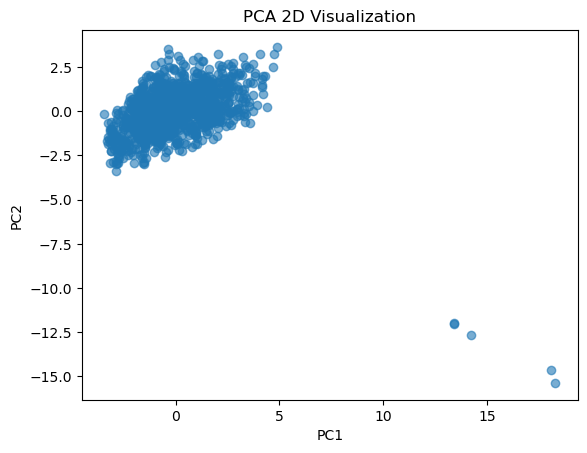

In [44]:
# PCA object create kar rahe hain aur data ko sirf 2 principal components mein reduce karna hai
pca = PCA(n_components=2, random_state=42)

# PCA ko data par fit karke original data ko naye 2D space (PC1 & PC2) mein transform karna
X_pca = pca.fit_transform(X)

# PCA ke transformed data ko DataFrame mein convert karna
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])

# Har Principal Component kitni information (variance) explain kar raha hai usay print karna
print('Explained variance ratio:', pca.explained_variance_ratio_)

# Dono Principal Components mil kar total kitni information preserve kar rahe hain usay print karna
print('Total explained variance:', pca.explained_variance_ratio_.sum())

# PCA ke transformed data ka 2D scatter plot banana
plt.scatter(pca_df['PC1'], pca_df['PC2'], alpha=0.6)

plt.title('PCA 2D Visualization')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

In [45]:
pca = PCA()
pca.fit(X)

print(np.cumsum(pca.explained_variance_ratio_))

[0.27697004 0.44359563 0.56440977 0.64246501 0.71316226 0.7793168
 0.84146892 0.90119937 0.92860404 0.94532548 0.95924055 0.97198927
 0.98452717 0.9902933  0.99404811 0.99684761 0.99957343 1.
 1.        ]


In [46]:
len(np.cumsum(pca.explained_variance_ratio_))

19

## 6. t-SNE Visualization

t-SNE non-linear visualization technique hai. Ye clusters ko visually separate dikhane mein helpful hoti hai.

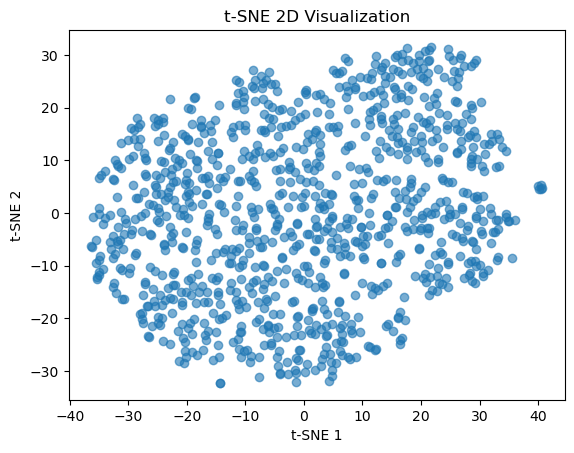

In [47]:
# t-SNE object create karna aur data ko 2 dimensions mein reduce karna
tsne = TSNE(
    n_components=2,        # Data ko 2 dimensions (2D) mein convert karna
    perplexity=30,         # Har point ke kitne neighboring points consider karne hain
    learning_rate='auto',  # Learning rate automatically select karna
    init='pca',            # Starting position ke liye PCA use karna
    random_state=42        # Har run par same result ke liye
)

# t-SNE ko data par apply karke original data ko 2D space mein transform karna
X_tsne = tsne.fit_transform(X)

# Transformed data ko DataFrame mein convert karna
tsne_df = pd.DataFrame(X_tsne, columns=['TSNE1', 'TSNE2'])

# t-SNE ka 2D scatter plot banana
plt.scatter(tsne_df['TSNE1'], tsne_df['TSNE2'], alpha=0.6)
plt.title('t-SNE 2D Visualization')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.show()

PCA information preserve karta hai, jab ke t-SNE neighborhood (nearby relationships) preserve karta hai.

## 7. K-Means Clustering

K-Means data ko K clusters mein divide karta hai. Pehle Elbow Method aur Silhouette Score se best K choose karte hain.

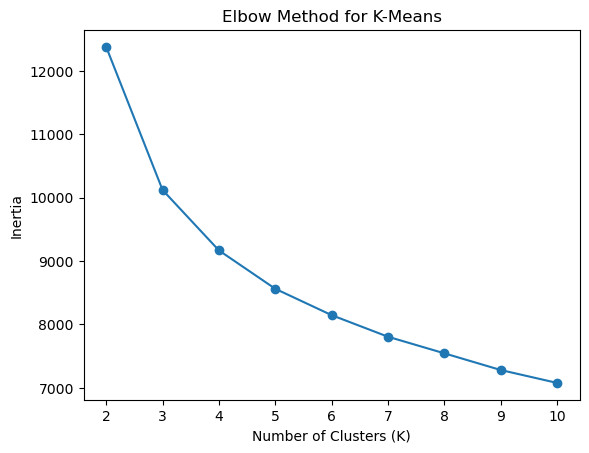

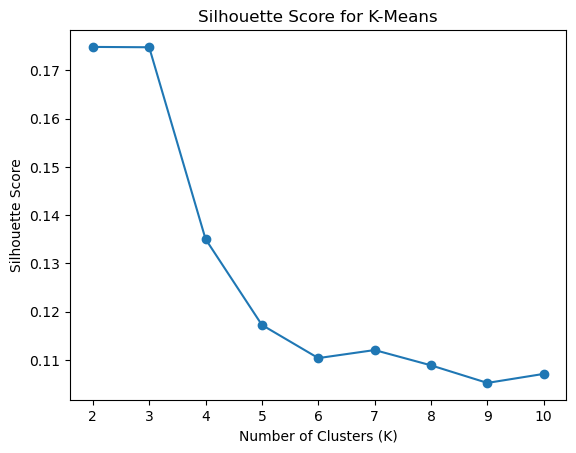

In [49]:
# Har K value ki Inertia store karne ke liye empty list
inertias = []

# Har K value ka Silhouette Score store karne ke liye empty list
silhouette_scores = []

# K (Number of Clusters) ki range 2 se 10 tak set karna
K_range = range(2, 11)

# Har K value ke liye K-Means algorithm run karna
for k in K_range:

    # K-Means object create karna
    km = KMeans(n_clusters=k, random_state=42, n_init=10)

    # Data par K-Means apply karna aur cluster labels predict karna
    labels = km.fit_predict(X)

    # Current K ki Inertia (Within Cluster Sum of Squares) list mein save karna
    inertias.append(km.inertia_)

    # Current K ka Silhouette Score calculate karke list mein save karna
    silhouette_scores.append(silhouette_score(X, labels))


# Elbow Method Graph 
# Inertia values ka line graph banana
plt.plot(list(K_range), inertias, marker='o')

# Graph ka title
plt.title('Elbow Method for K-Means')

# X-axis ka label (Number of Clusters)
plt.xlabel('Number of Clusters (K)')

# Y-axis ka label (Inertia)
plt.ylabel('Inertia')

# Graph display karna
plt.show()

# Silhouette Score Graph 

# Silhouette Score ka line graph banana
plt.plot(list(K_range), silhouette_scores, marker='o')

# Graph ka title
plt.title('Silhouette Score for K-Means')

# X-axis ka label (Number of Clusters)
plt.xlabel('Number of Clusters (K)')

# Y-axis ka label (Silhouette Score)
plt.ylabel('Silhouette Score')

# Graph display karna
plt.show()

Elbow graph mein clear elbow nazar nahi aa raha, lekin graph K = 3 ya K = 4 ke baad slow ho jata hai. Is liye 3 ya 4 clusters reasonable choice ho sakte hain.

Elbow Method se clear elbow point observe nahi hua, lekin graph K = 3 ke baad gradually flatten hona shuru ho gaya. Silhouette Score ka highest value bhi K = 2 aur K = 3 par mila. Dono evaluation methods ko dekhte hue K = 3 ko optimal number of clusters choose kiya gaya, kyun ke ye data ko meaningful groups mein divide karta hai aur clustering quality bhi comparatively behtar hai.

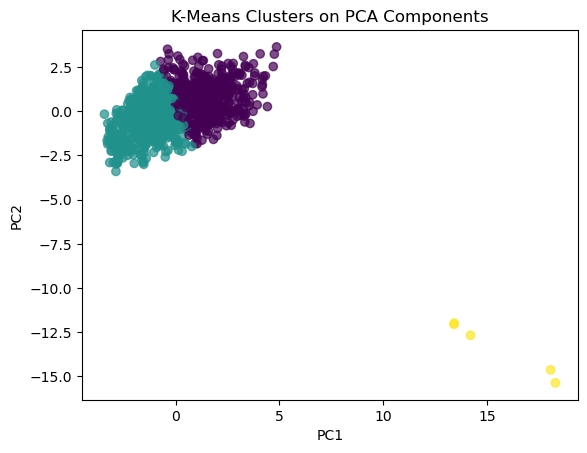

KMeans_Cluster
0    427
1    568
2      5
Name: count, dtype: int64

In [50]:
# Elbow Method aur Silhouette Score ke basis par best number of clusters select karna
best_k = 3

# K-Means Clustering object create karna
# n_clusters = Best number of clusters
# random_state = Har baar code run karne par same result ke liye
# n_init = Algorithm 10 baar different initial centroids ke sath chalega
# aur jis run ki Inertia sabse kam hogi usay final result maana jayega.
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)

# K-Means algorithm ko data par apply karna
# Har observation ko uske nearest cluster mein assign karna
# Cluster labels ko DataFrame ki nayi column "KMeans_Cluster" mein save karna
df_fe['KMeans_Cluster'] = kmeans.fit_predict(X)

# Cluster Visualization 
# PCA ke 2 components (PC1 aur PC2) par K-Means clusters ka scatter plot banana
# Har cluster ko different color mein show kiya jayega
plt.scatter(
    pca_df['PC1'],
    pca_df['PC2'],
    c=df_fe['KMeans_Cluster'],
    alpha=0.7
)

# Graph ka title
plt.title('K-Means Clusters on PCA Components')

# X-axis ka label
plt.xlabel('PC1')

# Y-axis ka label
plt.ylabel('PC2')

# Graph display karna
plt.show()

# Har cluster mein kitni observations hain unki counting dekhna
df_fe['KMeans_Cluster'].value_counts().sort_index()

K-Means algorithm ne dataset ko 3 clusters mein divide kiya. Purple aur Green clusters mein majority observations hain, jab ke Yellow cluster mein sirf kuch extreme observations hain jo baqi data se kaafi door hain. Purple aur Green clusters mein thora overlap bhi nazar aa raha hai, jis se pata chalta hai ke clusters ki separation bohat strong nahi hai. Ye observation Silhouette Score (~0.17) se bhi support hoti hai, jo relatively low clustering quality indicate karta hai.